# Point-in-Time Investable Universe

## TL;DR

The executed G1 summary derives signal-date, candidate, investable-observation, and distinct-bond
counts directly from the stored audit. The funnel uses explicit upstream stage names rather than row
order. Configuration lineage is recomputed from stored G0-G2 fingerprints and remains a separate
release gate from the universe quality checks.

## Context & Methods

G1 converts the broad convertible-bond mother universe into a point-in-time investable panel on a
biweekly signal calendar. Every security is evaluated using only information available by the
signal-day close.

### Key Assumptions

- Signals are anchored every 14 calendar days and shifted to the next market trading day when needed.
- A bond must have at least 11 market trading days of listing history.
- Twenty-day cumulative turnover must not exceed 100%.
- Remaining principal must be at least CNY 200 million and rating must be A or higher.
- A real market observation is required on the signal date.
- Event states first become visible on the next market trading day after disclosure.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "artifacts").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from within the repository checkout.")


PROJECT_ROOT = find_project_root()
ARTIFACTS = PROJECT_ROOT / "artifacts"
ASSETS = PROJECT_ROOT / "docs" / "assets"
ASSETS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cb_quant.notebook_quality import (
    G1_FUNNEL_STAGE_LABELS,
    build_g1_headline,
    build_lineage_gate,
    translate_g1_funnel_stages,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "savefig.bbox": "tight",
})


### Load Existing G1 Artifacts


In [2]:
def read_json(relative_path: str) -> dict:
    return json.loads((ARTIFACTS / relative_path).read_text(encoding="utf-8"))


g0_audit = read_json("G0/research_config_validation_v1.json")
g1_audit = read_json("G1/universe_audit_v1.json")
g2_audit = read_json("G2/valuation_factor_audit_v1.json")
counts = pd.read_parquet(ARTIFACTS / "G1/universe_counts_by_signal_date_v1.parquet")
raw_funnel = pd.read_parquet(ARTIFACTS / "G1/universe_funnel_by_signal_date_v1.parquet")
event_checks = pd.read_parquet(ARTIFACTS / "G1/event_boundary_checks_v1.parquet")

counts["signal_date"] = pd.to_datetime(counts["signal_date"])
raw_funnel.columns = ["stage", "remaining_bonds", "signal_date"]
raw_funnel["signal_date"] = pd.to_datetime(raw_funnel["signal_date"])
observed_stage_names = set(raw_funnel["stage"].dropna().astype(str).unique())
missing_stage_names = set(G1_FUNNEL_STAGE_LABELS).difference(observed_stage_names)
if missing_stage_names:
    raise ValueError(f"Missing expected upstream G1 funnel stage count: {len(missing_stage_names)}")
raw_funnel["Stage"] = translate_g1_funnel_stages(raw_funnel["stage"])
stage_labels = list(G1_FUNNEL_STAGE_LABELS.values())


## Data Quality Gate


In [3]:
lineage_gate = build_lineage_gate(
    {"G0": g0_audit, "G1": g1_audit, "G2": g2_audit}
)
quality_gate = pd.DataFrame(
    [
        ["Stored audit status", g1_audit["status"]],
        ["Configuration lineage gate", lineage_gate["status"]],
        ["Lineage detail", lineage_gate["detail"]],
        ["Duplicate signal-date/bond keys", g1_audit["duplicate_signal_bond_keys"]],
        ["Eligibility formula mismatches", g1_audit["eligibility_formula_mismatches"]],
        ["Event boundary failures", g1_audit["event_boundary_check_failures"]],
        ["Ambiguous industry rows", g1_audit["industry_ambiguous_rows"]],
    ],
    columns=["Check", "Observed result"],
)
event_summary = (
    event_checks.groupby("event_type", as_index=False)
    .agg(Checks=("passed", "size"), Passed=("passed", "sum"))
)
event_summary["Failures"] = event_summary["Checks"] - event_summary["Passed"]
event_summary["Event type"] = event_summary["event_type"].str.title()
display(quality_gate)
display(event_summary[["Event type", "Checks", "Passed", "Failures"]])

,Check,Observed result
0,Stored audit status,pass
1,Configuration lineage gate,pass
2,Lineage detail,Stored stage configuration fingerprints match.
3,Duplicate signal-date/bond keys,0
4,Eligibility formula mismatches,0
5,Event boundary failures,0
6,Ambiguous industry rows,0


,Event type,Checks,Passed,Failures
0,Rating,12,12,0
1,Share,12,12,0


The lineage row is derived from stored G0-G2 audit fingerprints. They match after the unified final
build, so the configuration lineage gate passes. Universe
counts and checks remain descriptive properties of the stored G1 artifact.

## Results


In [4]:
funnel_summary = (
    raw_funnel.groupby("Stage", observed=True)["remaining_bonds"]
    .agg(["mean", "min", "max"])
    .reindex(stage_labels)
    .reset_index()
    .rename(columns={"mean": "Mean bonds", "min": "Minimum", "max": "Maximum"})
)

exclusion_labels = {
    "not_yet_listed": "Not yet listed",
    "remaining_balance_below_minimum": "Balance below minimum",
    "turnover_above_maximum": "Turnover above maximum",
    "no_signal_day_trade": "No signal-day trade",
    "listing_age_below_minimum": "Listing age below minimum",
    "rating_below_minimum": "Rating below minimum",
    "rating_missing": "Rating missing",
}
exclusion_summary = pd.DataFrame(
    [
        [exclusion_labels.get(reason, reason.replace("_", " ").title()), count]
        for reason, count in g1_audit["primary_exclusion_reason_counts"].items()
        if reason != "eligible"
    ],
    columns=["Primary exclusion reason", "Observations"],
).sort_values("Observations", ascending=False)

headline = build_g1_headline(g1_audit)
display(headline)
display(funnel_summary.round(1))
display(exclusion_summary)


,Metric,Observed value
0,Signal dates,222
1,Candidate observations,208680
2,Investable observations,44728
3,Distinct investable bonds,846


,Stage,Mean bonds,Minimum,Maximum
0,Ordinary CB with observed daily data,940.0,940,940
1,Listed for at least 11 market days,541.5,33,934
2,20-day cumulative turnover at or below 100%,400.6,33,726
3,Remaining principal at least CNY 200 million,219.4,32,424
4,Rating A or higher,215.4,32,418
5,Traded on the signal date,201.5,32,408


,Primary exclusion reason,Observations
0,Not yet listed,87505
1,Balance below minimum,40243
2,Turnover above maximum,31265
3,No signal-day trade,3096
4,Listing age below minimum,970
5,Rating below minimum,733
6,Rating missing,140


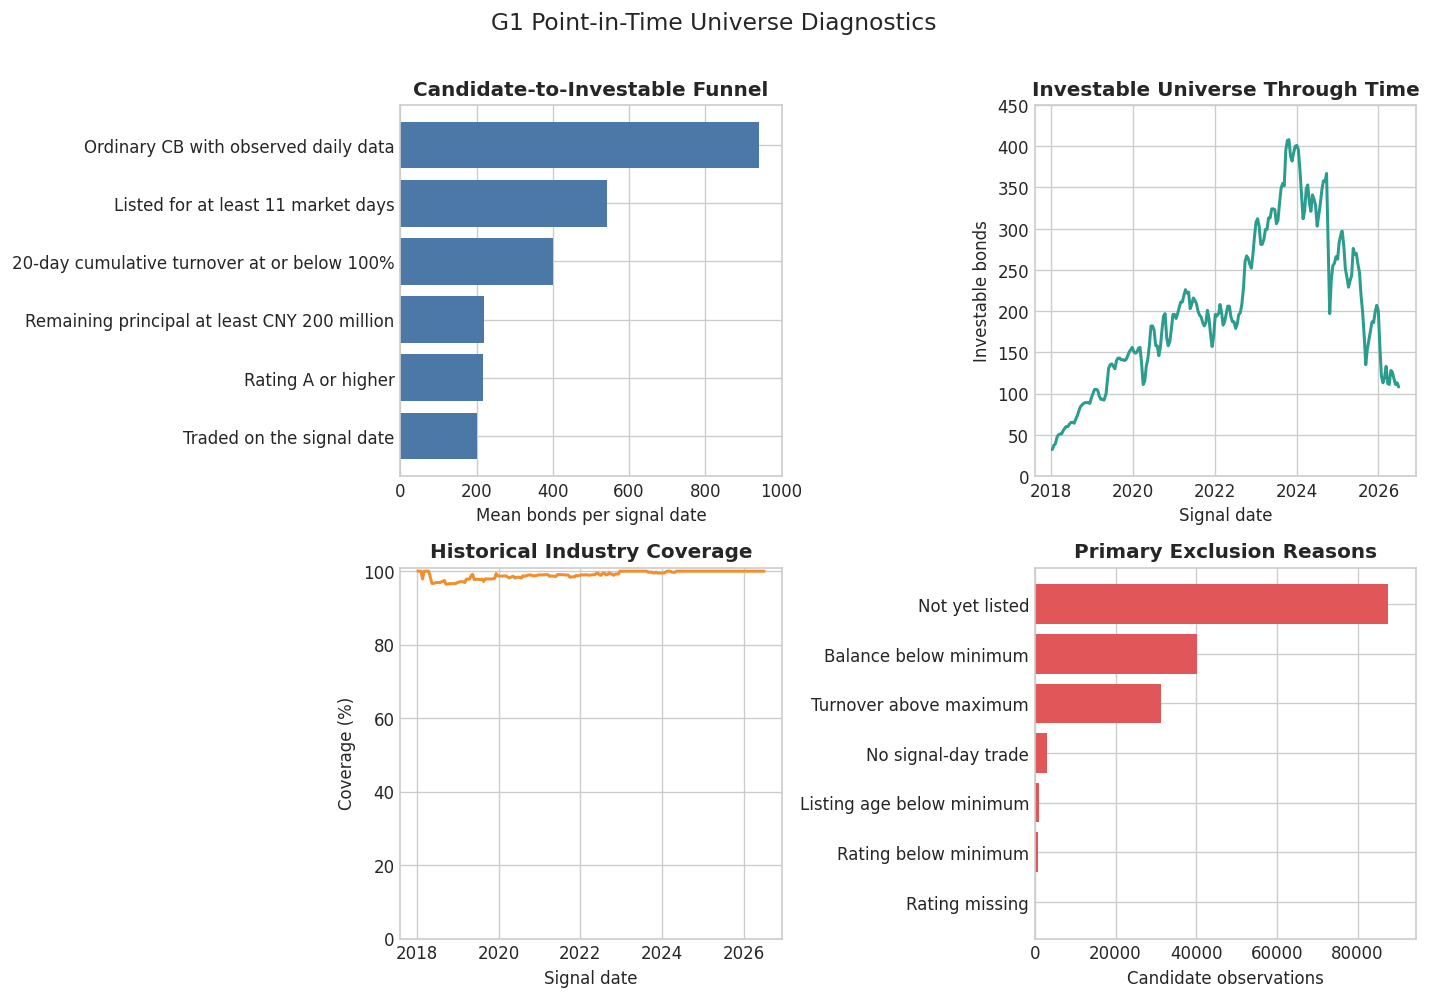

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.2))

funnel_plot = funnel_summary.iloc[::-1]
axes[0, 0].barh(funnel_plot["Stage"], funnel_plot["Mean bonds"], color="#4C78A8")
axes[0, 0].set_xlim(0, 1000)
axes[0, 0].set_xlabel("Mean bonds per signal date")
axes[0, 0].set_title("Candidate-to-Investable Funnel")

axes[0, 1].plot(counts["signal_date"], counts["eligible_count"], color="#2A9D8F", linewidth=1.8)
axes[0, 1].set_ylim(0, max(450, counts["eligible_count"].max() * 1.05))
axes[0, 1].set_xlabel("Signal date")
axes[0, 1].set_ylabel("Investable bonds")
axes[0, 1].set_title("Investable Universe Through Time")

axes[1, 0].plot(counts["signal_date"], counts["eligible_industry_coverage"] * 100, color="#F28E2B", linewidth=1.8)
axes[1, 0].set_ylim(0, 101)
axes[1, 0].set_xlabel("Signal date")
axes[1, 0].set_ylabel("Coverage (%)")
axes[1, 0].set_title("Historical Industry Coverage")

for date_axis in (axes[0, 1], axes[1, 0]):
    date_axis.xaxis.set_major_locator(mdates.YearLocator(2))
    date_axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

exclusion_plot = exclusion_summary.sort_values("Observations")
axes[1, 1].barh(exclusion_plot["Primary exclusion reason"], exclusion_plot["Observations"], color="#E15759")
axes[1, 1].set_xlim(0, exclusion_plot["Observations"].max() * 1.08)
axes[1, 1].set_xlabel("Candidate observations")
axes[1, 1].set_title("Primary Exclusion Reasons")

fig.suptitle("G1 Point-in-Time Universe Diagnostics", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(ASSETS / "g1_point_in_time_universe_diagnostics.png")
plt.show()


## Takeaways

- The investable panel is a filtered point-in-time cross-section, not the full set of listed bonds.
- Listing status, remaining principal, and turnover explain most candidate exclusions.
- The displayed counts and event checks are derived from the stored G1 audit.
- Explicit upstream funnel names are translated only after every observed value is recognized.
- These are universe-construction diagnostics only; no future return or factor efficacy is tested.